# No-UDU Candidate Sample Construction

This notebook builds a high-confidence **no-UDU control sample** from LA City parcels for the 2014→2017 LARIAC epoch, and compares it against known UDU (Unpermitted Dwelling Unit) amnesty filings.

**Outline:**
1. Load symdiff building-change data and merge with 2017 assessor records
2. Apply per-use-type structural filters to identify clean no-UDU parcels
3. Load known UDU cases and engineer comparison features
4. Integrate TCAC opportunity data and spatial features
5. Detect and remove UDU-similar parcels from the control set (Mahalanobis + LightGBM)
6. Save checkpoints for the reporting notebook (nb_10)

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

os.chdir('../..')
print(f'Working directory: {os.getcwd()}')

SYMDIFF_PATH = 'data/04_results/lariac_symdiff_lacity.gpkg'
DB_PATH      = '/Users/adamswietek/Documents/PostDoc/data/raw_la/parcels/AssessorParcelsData_MultRolls.db'
MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
FIG_DIR      = 'notebooks/tasks/figures/'

EPOCH_LABEL  = '2014→2017'   # epoch whose change_type labels we use
LAYER_NAME   = 'symdiff_2014_2017'

# Ordered for legend clarity
CHANGE_ORDER = ['new_parcel', 'added_structure', 'extended',
                'no_change',
                'reduced', 'removed_structure', 'demolished']

CHANGE_COLORS = {
    'new_parcel':        '#1a9641',
    'added_structure':   '#a6d96a',
    'extended':          "#0344e6",
    'no_change':         '#888888',
    'reduced':           '#fdae61',
    'removed_structure': '#d7191c',
    'demolished':        '#7b0000',
}

df = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer="symdiff_2014_2017").drop(columns="geometry"),
    gpd.read_file(SYMDIFF_PATH, layer="symdiff_2017_2020").drop(columns="geometry"),
], ignore_index=True)

df.to_csv("data/04_results/lariac_symdiff_lacity.csv", index=False)
print(f"{len(df):,} rows  ×  {df.shape[1]} cols")
print(df.columns.tolist())

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing
1,250,890 rows  ×  15 cols
['AIN', 'area_2014', 'area_2017', 'n_2014', 'n_2017', 'area_net', 'n_delta', 'epoch', 'neighborhood', 'shift_dx_m', 'shift_dy_m', 'n_switchers', 'change_type', 'area_2020', 'n_2020']


## 1. Load data

In [2]:
parcel_ref = gpd.read_file(MASTER_PATH, layer='2017', columns=['AIN', 'geometry'])
parcel_ref['AIN'] = parcel_ref['AIN'].astype(str)


In [3]:
g = df.groupby(['AIN','epoch'])
g = g.size()[(g.size() == 1)]
ains = g.index.get_level_values('AIN').unique()
g.unstack()#.describe()

# df.groupby(['AIN','epoch']).size().unstack().describe()

epoch,2014→2017,2017→2020
AIN,,
2004001003,1.0,1.0
2004001004,1.0,1.0
2004001005,1.0,1.0
2004001008,1.0,1.0
2004001009,1.0,1.0
...,...,...
7563037052,1.0,1.0
7563037053,1.0,1.0
7563037054,1.0,1.0


In [4]:
DATA = df.query('AIN in @ains')

## 2. Merge symdiff with assessor data

In [5]:
assr_2017 = (
    gpd.read_file(MASTER_PATH, layer='2017',
                  columns=['AIN', 'assr_sqftmain', 'lar_area', 'lar_n_structures',
                           'lar_floorarea', 'LotArea', 'usetype'])
    .drop(columns='geometry')
    .drop_duplicates('AIN')
    .assign(AIN=lambda x: x['AIN'].astype(str))
)

print(f"assessor_lariac 2017 rows: {len(assr_2017):,}")
print(assr_2017['usetype'].value_counts().head(8))

assessor_lariac 2017 rows: 1,452,636
usetype
Single Family Residence                               1121732
Double, Duplex, or Two Units                            81523
Five or More Units or Apartments (Any Combination)      59142
Three Units (Any Combination)                           28434
Four Units  (Any Combination)                           26331
Store                                                   15443
Light Manufacturing                                     15255
Government Owned Property                               13235
Name: count, dtype: int64


In [6]:
# 2014 assessor sqftmain — to check value stability across the LARIAC epoch
assr_2014 = (
    gpd.read_file(MASTER_PATH, layer='2014', columns=['AIN', 'assr_sqftmain'])
    .drop(columns='geometry')
    .drop_duplicates('AIN')
    .assign(AIN=lambda x: x['AIN'].astype(str))
    .rename(columns={'assr_sqftmain': 'assr_sqftmain_2014'})
)
print(f"assessor_lariac 2014 rows: {len(assr_2014):,}")


assessor_lariac 2014 rows: 1,429,472


In [7]:
SQM_TO_SQFT = 10.7639

symdiff_17 = DATA.query("epoch == '2014→2017'").copy()
symdiff_17['area_2017_sqft'] = symdiff_17['area_2017'] * SQM_TO_SQFT

merged = (
    symdiff_17
    .merge(assr_2017, on='AIN', how='inner')
    .merge(assr_2014, on='AIN', how='left')
)
merged = merged.rename(columns={'lar_area': 'lar_area_sqft'})

merged['delta_symdiff_assr'] = merged['area_2017_sqft'] - merged['assr_sqftmain']
merged['delta_lar_assr']     = merged['lar_area_sqft']  - merged['assr_sqftmain']
merged['delta_symdiff_lar']  = merged['area_2017_sqft'] - merged['lar_area_sqft']
# Height-adjusted ratio: lar_floorarea (footprint × LARIAC-estimated floors) vs assessor
merged['ratio_floor_assr']   = merged['lar_floorarea']  / merged['assr_sqftmain'].replace(0, np.nan)
merged['assr_stable']        = merged['assr_sqftmain']  == merged['assr_sqftmain_2014']

print(f"Symdiff 2014→2017 parcels : {len(symdiff_17):,}")
print(f"Matched to assessor/LARIAC: {len(merged):,}")
merged[['AIN','area_2017_sqft','lar_area_sqft','lar_floorarea','assr_sqftmain',
        'LotArea','delta_symdiff_assr','ratio_floor_assr','assr_stable','change_type']].head()


Symdiff 2014→2017 parcels : 625,663
Matched to assessor/LARIAC: 625,663


,AIN,area_2017_sqft,lar_area_sqft,lar_floorarea,assr_sqftmain,LotArea,delta_symdiff_assr,ratio_floor_assr,assr_stable,change_type
0,4363001903,4.021984e+06,4.163732e+06,2.647947e+07,0,1.170509e+07,4.021984e+06,NaN,True,no_change
1,4129027902,3.153857e+06,3.169412e+06,2.171114e+07,373394,2.406701e+07,2.780463e+06,58.145393,False,removed_structure
2,4129028900,2.937236e+06,2.939893e+06,1.018653e+07,244262,2.682030e+07,2.692974e+06,41.703305,True,no_change
3,4129026903,1.504848e+06,1.519619e+06,8.652185e+06,0,1.637061e+07,1.504848e+06,NaN,True,removed_structure
4,2673021041,1.634056e+06,1.634527e+06,7.493549e+06,393032,3.089694e+06,1.241024e+06,19.066003,True,no_change


In [8]:
AVG_STOREY_H = 14  # ft — matches HEIGHT / 14 convention used in assessor_lariac.gpkg

# n_floors: back-calculated from lar_floorarea = lar_area × round(HEIGHT / 14)
# For single-structure parcels this is the floor count of that one building.
# For multi-structure parcels it is the weighted-average floor count across all buildings.
n_floors = (
    merged['lar_floorarea']
    .div(merged['lar_area_sqft'].replace(0, np.nan))
    .fillna(1)
    .clip(lower=1)
)

# gross_sqft_geom: geometry-derived footprint (symdiff) × height-implied floor count
merged['n_floors_lar']     = n_floors.round(1)
merged['gross_sqft_geom']  = (merged['area_2017_sqft'] * n_floors).round()
merged['delta_gross_assr'] = merged['gross_sqft_geom'] - merged['assr_sqftmain']

print("New columns added to merged:")
merged[['AIN','area_2017_sqft','n_floors_lar','gross_sqft_geom','assr_sqftmain','delta_gross_assr']].head(8)


New columns added to merged:


,AIN,area_2017_sqft,n_floors_lar,gross_sqft_geom,assr_sqftmain,delta_gross_assr
0,4363001903,4.021984e+06,6.4,25578016.0,0,25578016.0
1,4129027902,3.153857e+06,6.9,21604585.0,373394,21231191.0
2,4129028900,2.937236e+06,3.5,10177326.0,244262,9933064.0
3,4129026903,1.504848e+06,5.7,8568084.0,0,8568084.0
4,2673021041,1.634056e+06,4.6,7491388.0,393032,7098356.0
5,2764014906,1.376670e+06,4.3,5907410.0,0,5907410.0
6,5223034908,1.078703e+06,5.7,6188249.0,0,6188249.0
7,5534037009,1.159223e+06,3.8,4455595.0,67126,4388469.0


## 2b. No-UDU candidate set

Criteria (all must hold):
1. **No footprint change**: `change_type == no_change` and `n_delta == 0`  
2. **Assessor stable**: `SQFTmain` identical in 2014 and 2017 rolls, and > 0  
3. **Small residential lot**: `LotArea < 10,000 sq ft`  
4. **Single LARIAC building**: reduces accessory structure noise  
5. **Height-adjusted area consistent**: `lar_floorarea / assr_sqftmain` in [0.5, 2.5]  
   *(LARIAC height ÷ 14 ft estimates floors; ratio bounds allow for measurement imprecision)*

In [10]:
# ── Per-type thresholds ───────────────────────────────────────────────────────
# n_structures and lot area are relaxed for denser types so the control sample
# reflects the same property types that dominate UDU filings.
TYPE_CONFIG = {
    'Single Family Residence': {
        'max_n_struct': 1, 'max_lot': 10_000, 'ratio_lo': 0.5, 'ratio_hi': 2.5,
    },
    'Double, Duplex, or Two Units': {
        'max_n_struct': 2, 'max_lot': 12_000, 'ratio_lo': 0.3, 'ratio_hi': 4.0,
    },
    'Three Units (Any Combination)': {
        'max_n_struct': 3, 'max_lot': 15_000, 'ratio_lo': 0.3, 'ratio_hi': 4.0,
    },
    'Four Units  (Any Combination)': {
        'max_n_struct': 4, 'max_lot': 20_000, 'ratio_lo': 0.3, 'ratio_hi': 4.0,
    },
    'Five or More Units or Apartments (Any Combination)': {
        'max_n_struct': 8, 'max_lot': 30_000, 'ratio_lo': 0.2, 'ratio_hi': 6.0,
    },
}
DEFAULT_CONFIG = {'max_n_struct': 1, 'max_lot': 10_000, 'ratio_lo': 0.5, 'ratio_hi': 2.5}

# ── Back-fill columns if prior cells haven't run ─────────────────────────────
m = merged.copy()

if 'usetype' not in m.columns:
    m = m.merge(
        gpd.read_file(MASTER_PATH, layer='2017', columns=['AIN','usetype'])
        .drop(columns='geometry').drop_duplicates('AIN')
        .assign(AIN=lambda x: x['AIN'].astype(str)),
        on='AIN', how='left'
    )
missing_2017 = [c for c in ('lar_floorarea', 'LotArea') if c not in m.columns]
if missing_2017:
    m = m.merge(
        gpd.read_file(MASTER_PATH, layer='2017', columns=['AIN'] + missing_2017)
        .drop(columns='geometry').drop_duplicates('AIN')
        .assign(AIN=lambda x: x['AIN'].astype(str)),
        on='AIN', how='left'
    )
if 'assr_sqftmain_2014' not in m.columns:
    m = m.merge(
        gpd.read_file(MASTER_PATH, layer='2014', columns=['AIN','assr_sqftmain'])
        .drop(columns='geometry').drop_duplicates('AIN')
        .assign(AIN=lambda x: x['AIN'].astype(str))
        .rename(columns={'assr_sqftmain': 'assr_sqftmain_2014'}),
        on='AIN', how='left'
    )
if 'assr_stable' not in m.columns:
    m['assr_stable'] = m['assr_sqftmain'] == m['assr_sqftmain_2014']
if 'ratio_floor_assr' not in m.columns:
    m['ratio_floor_assr'] = m['lar_floorarea'] / m['assr_sqftmain'].replace(0, np.nan)

# ── Shared structural filters (apply to all types) ───────────────────────────
base = m[
    (m.change_type    == 'no_change') &
    (m.n_delta        == 0) &
    (m.assr_sqftmain  >  0) &
    m.assr_stable
].copy()

# ── Per-type filter ───────────────────────────────────────────────────────────
parts = []
type_rows = []

known_types = set(TYPE_CONFIG.keys())

for utype, cfg in TYPE_CONFIG.items():
    sub = base[base.usetype == utype]
    filtered = sub[
        (sub.LotArea          <  cfg['max_lot']) &
        (sub.lar_n_structures <= cfg['max_n_struct']) &
        sub.ratio_floor_assr.between(cfg['ratio_lo'], cfg['ratio_hi'])
    ]
    parts.append(filtered)
    type_rows.append({'usetype': utype, 'before': len(sub), 'after': len(filtered),
                      'pct_kept': f"{len(filtered)/max(len(sub),1)*100:.0f}%",
                      'max_n_struct': cfg['max_n_struct'],
                      'max_lot': f"{cfg['max_lot']:,}"})

# Other use types — apply default thresholds
other = base[~base.usetype.isin(known_types)]
cfg = DEFAULT_CONFIG
other_filt = other[
    (other.LotArea          <  cfg['max_lot']) &
    (other.lar_n_structures <= cfg['max_n_struct']) &
    other.ratio_floor_assr.between(cfg['ratio_lo'], cfg['ratio_hi'])
]
parts.append(other_filt)
type_rows.append({'usetype': '(all other types)', 'before': len(other), 'after': len(other_filt),
                  'pct_kept': f"{len(other_filt)/max(len(other),1)*100:.0f}%",
                  'max_n_struct': cfg['max_n_struct'], 'max_lot': f"{cfg['max_lot']:,}"})

no_udu = pd.concat(parts, ignore_index=True).drop_duplicates('AIN')

# ── Summary ───────────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(type_rows)
print(f"Base (no_change + assr_stable + assr>0): {len(base):,}\n")
print(summary_df.to_string(index=False))
print(f"\nTotal no_udu: {len(no_udu):,}")


Base (no_change + assr_stable + assr>0): 523,767

                                           usetype  before  after pct_kept  max_n_struct max_lot
                           Single Family Residence  387573 125996      33%             1  10,000
                      Double, Duplex, or Two Units   38610  29290      76%             2  12,000
                     Three Units (Any Combination)   13100  12141      93%             3  15,000
                     Four Units  (Any Combination)   13419  13152      98%             4  20,000
Five or More Units or Apartments (Any Combination)   32357  30167      93%             8  30,000
                                 (all other types)   38708  16338      42%             1  10,000

Total no_udu: 227,084


In [11]:
no_udu[['LotArea','assr_sqftmain','lar_area_sqft','lar_floorarea',
        'ratio_floor_assr','delta_symdiff_assr','neighborhood']].describe().round(1)


,LotArea,assr_sqftmain,lar_area_sqft,lar_floorarea,ratio_floor_assr,delta_symdiff_assr
count,227084.0,227084.0,227084.0,227084.0,227084.0,227084.0
mean,6782.3,3233.2,2943.0,4575.9,1.6,-314.1
std,2730.3,4681.3,1912.4,5683.8,0.4,3396.0
min,158.8,85.0,33.3,66.7,0.2,-323230.8
25%,5398.7,1450.0,2046.6,2301.4,1.3,-512.9
50%,6504.5,1986.0,2544.2,3041.3,1.5,363.8
75%,7591.8,3226.0,3161.1,4991.9,1.8,888.9
max,30000.0,346187.0,29104.9,436370.1,6.0,5537.0


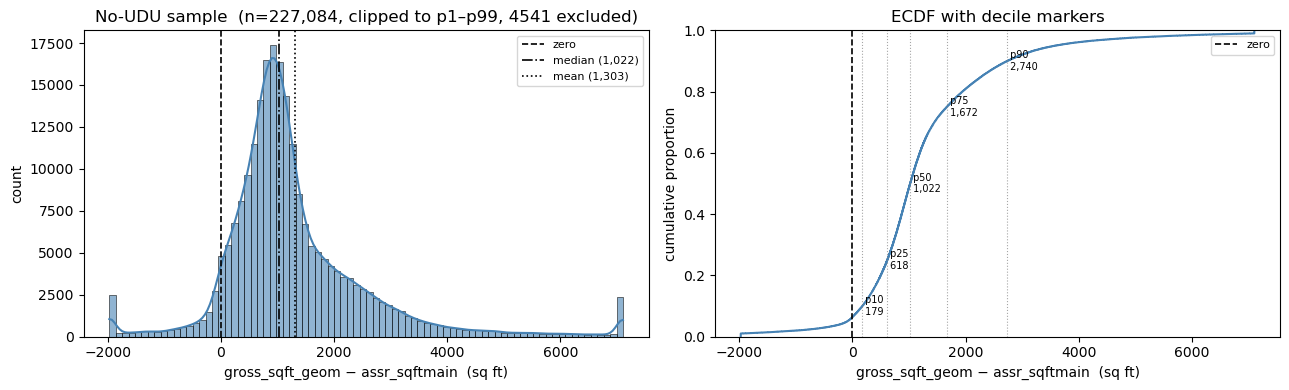

count    227084.0
mean       1303.4
std        1783.8
min      -70383.0
25%         618.0
50%        1022.0
75%        1672.0
max      126837.0
Name: delta_gross_assr, dtype: float64


In [12]:
import seaborn as sns

# Ensure delta_gross_assr is present
if 'delta_gross_assr' not in no_udu.columns:
    n_floors = (no_udu['lar_floorarea'] / no_udu['lar_area_sqft'].replace(0, np.nan)).fillna(1).clip(lower=1)
    no_udu = no_udu.copy()
    no_udu['gross_sqft_geom']  = (no_udu['area_2017_sqft'] * n_floors).round()
    no_udu['delta_gross_assr'] = no_udu['gross_sqft_geom'] - no_udu['assr_sqftmain']

d = no_udu['delta_gross_assr'].dropna()

# Clip to 1st–99th percentile for readability; note how many are excluded
p1, p99 = d.quantile([0.01, 0.99])
d_clip   = d.clip(p1, p99)
n_out    = (d < p1).sum() + (d > p99).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── left: histogram + KDE ──────────────────────────────────────────────────
ax = axes[0]
sns.histplot(d_clip, bins=80, kde=True, color='steelblue', alpha=0.6, ax=ax)
for val, ls, label in [
    (0,        '--', 'zero'),
    (d.median(),'-.', f'median ({d.median():,.0f})'),
    (d.mean(),  ':',  f'mean ({d.mean():,.0f})'),
]:
    ax.axvline(val, color='black', linestyle=ls, linewidth=1.2, label=label)
ax.set_xlabel('gross_sqft_geom − assr_sqftmain  (sq ft)')
ax.set_ylabel('count')
ax.set_title(f'No-UDU sample  (n={len(d):,}, clipped to p1–p99, {n_out} excluded)')
ax.legend(fontsize=8)

# ── right: ECDF ───────────────────────────────────────────────────────────
ax2 = axes[1]
sns.ecdfplot(d_clip, color='steelblue', ax=ax2)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.2, label='zero')
for pct in [0.10, 0.25, 0.50, 0.75, 0.90]:
    v = d.quantile(pct)
    ax2.axvline(v, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    ax2.text(v, pct, f' p{int(pct*100)}\n {v:,.0f}', fontsize=7, va='center')
ax2.set_xlabel('gross_sqft_geom − assr_sqftmain  (sq ft)')
ax2.set_ylabel('cumulative proportion')
ax2.set_title('ECDF with decile markers')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(d.describe().round(1))


In [13]:
usetype_summary = (
    no_udu
    .groupby("usetype", dropna=False)
    .agg(
        n                  = ("delta_gross_assr", "count"),
        mean_assr_sqftmain = ("assr_sqftmain",    "mean"),
        mean_delta         = ("delta_gross_assr",  "mean"),
        median_delta       = ("delta_gross_assr",  "median"),
        std_delta          = ("delta_gross_assr",  "std"),
        p25_delta          = ("delta_gross_assr",  lambda x: x.quantile(0.25)),
        p75_delta          = ("delta_gross_assr",  lambda x: x.quantile(0.75)),
    )
    .sort_values("n", ascending=False)
    .round(1)
)
usetype_summary.head(6)


,n,mean_assr_sqftmain,mean_delta,median_delta,std_delta,p25_delta,p75_delta
usetype,,,,,,,
Single Family Residence,125996,1763.0,1136.7,999.0,762.5,701.0,1387.0
Five or More Units or Apartments (Any Combination),30167,9814.6,2015.7,1719.0,3895.1,641.0,2857.0
"Double, Duplex, or Two Units",29290,2104.4,1208.6,934.0,1012.6,572.0,1566.0
Four Units (Any Combination),13152,3586.7,1282.4,1136.0,1223.3,625.0,1796.2
Three Units (Any Combination),12141,2549.6,1408.6,1159.0,1132.0,645.0,2024.0
Store,4465,3825.4,1224.0,220.0,2343.0,6.0,1182.0


## 3. Known-UDU vs No-UDU sample

In [14]:
ADP_PATH = "data/04_results/lacity_apd_building_features.gpkg"
UDU_PATH = "data/01_raw/UDU Report 02_10_2026.csv"

# ADP is a 3-epoch panel (RollYear 2014 / 2017 / 2020) — filter to 2017.
ADP_COLS = [
    "AIN", "RollYear",
    "YearBuilt", "EffectiveYearBuilt",
    "SQFTmain", "Bedrooms", "Bathrooms", "Units",
    "totBuildingDataLines", "ImprovementValue", "LandValue", "TotalValue",
    "shape.area.sum", "shape.area.max", "shape.floorarea.sum", "shape.n_buildings",
    "parcels.area", "parcels.far",
    "sp.bar", "sp.far", "sp.ratio.floorarea", "sp.resid.floorarea",
    "LotArea", "GeneralUseType", "SpecificUseType",
    "Neighborhood", "CENTER_LAT", "CENTER_LON",
]
adp = (
    gpd.read_file(ADP_PATH, layer="lacity_apd_building_features", columns=ADP_COLS)
    .drop(columns="geometry")
    .dropna(subset=["AIN"])
    .assign(AIN=lambda x: x["AIN"].astype(int).astype(str))
    .query("RollYear == 2017")
    .drop_duplicates("AIN")
)
print(f"ADP 2017 rows: {len(adp):,}")

# ── Known UDU report ─────────────────────────────────────────────────────────
udu_raw = pd.read_csv(UDU_PATH, parse_dates=["filing_date", "case_completion_date"])
udu_raw["AIN"] = udu_raw["assessor_parcel_number"].astype(str)
print(f"Known UDU cases: {len(udu_raw):,}  |  unique AINs: {udu_raw["AIN"].nunique():,}")


ADP 2017 rows: 581,764
Known UDU cases: 448  |  unique AINs: 443


### 3a. Build labelled samples

In [15]:
# ── Build UDU sample: join symdiff+assessor metrics and ADP features ──────────
udu = (
    udu_raw[['AIN', 'filing_date', 'Approved Units']]
    .drop_duplicates('AIN')           # keep one row per parcel
    .merge(merged, on='AIN', how='inner')
    .merge(adp,    on='AIN', how='left')
)
print(f"Known UDU matched to merged:      {len(udu):,}")

# ── Attach ADP features to no_udu sample too ─────────────────────────────────
no_udu_adp = no_udu.merge(adp, on='AIN', how='left')

# ── Derived features (both sets) ─────────────────────────────────────────────
for df in (udu, no_udu_adp):
    df['age_2017']       = 2017 - df['YearBuilt']
    df['eff_age_2017']   = 2017 - df['EffectiveYearBuilt']

# ── Label and stack ───────────────────────────────────────────────────────────
udu['label']       = 'udu'
no_udu_adp['label'] = 'no_udu'

COMPARE_COLS = [
    'label', 'AIN',
    # size / area
    'assr_sqftmain', 'area_2017_sqft', 'gross_sqft_geom', 'delta_gross_assr',
    'LotArea_x',                        # from no_udu / merged (sq ft)
    # morphology
    'shape.area.sum', 'shape.floorarea.sum', 'shape.n_buildings',
    'parcels.far', 'sp.far', 'sp.bar', 'sp.ratio.floorarea',
    # age
    'YearBuilt', 'age_2017', 'eff_age_2017',
    # assessor
    'Bedrooms', 'Bathrooms', 'Units',
    # use type
    'SpecificUseType', 'GeneralUseType',
    # location
    'neighborhood', 'Neighborhood',
    # new engineered features
    'renov_gap', 'bath_per_unit', 'bdrm_per_sqft', 'imp_per_sqft',
    'struct_unit_gap', 'multi_bldg_flag', 'resid_floor_gap',
    'lot_elongation', 'n_udu_tract', 'GEOID_TRACT',
]
# keep only columns that exist in both
avail = [c for c in COMPARE_COLS if c in udu.columns and c in no_udu_adp.columns]
combined = pd.concat([udu[avail], no_udu_adp[avail]], ignore_index=True)

print(f"Combined rows — udu: {(combined.label=='udu').sum():,}  |  no_udu: {(combined.label=='no_udu').sum():,}")


Known UDU matched to merged:      433
Combined rows — udu: 433  |  no_udu: 227,084


### 3b. Feature engineering

In [16]:
# ── Feature engineering — derived features for both udu and no_udu_adp ─────────

# Tract-level local UDU intensity
TRACT_PATH = "data/03_processed/assessor_udu_tracts.gpkg"
tract_data = (
    gpd.read_file(TRACT_PATH, layer="parcels", columns=["AIN","GEOID_TRACT","n_udu"])
    .drop(columns="geometry")
    .assign(AIN=lambda x: x["AIN"].astype(str))
    .drop_duplicates("AIN")
    .rename(columns={"n_udu": "n_udu_tract"})
)

# Parcel elongation (proxy for deep lot) from geometry — UTM metres
b = parcel_ref.geometry.bounds
parcel_shape = parcel_ref[["AIN"]].copy()
parcel_shape["bbox_w"] = b["maxx"] - b["minx"]
parcel_shape["bbox_h"] = b["maxy"] - b["miny"]
parcel_shape["lot_elongation"] = (
    parcel_shape[["bbox_w","bbox_h"]].max(axis=1)
    / parcel_shape[["bbox_w","bbox_h"]].min(axis=1).replace(0, np.nan)
)

def add_features(df):
    df = df.copy()
    # From ADP columns
    df["renov_gap"]       = (df["EffectiveYearBuilt"] - df["YearBuilt"]).clip(lower=0)
    df["bath_per_unit"]   = df["Bathrooms"]       / df["Units"].replace(0, np.nan)
    df["bdrm_per_sqft"]   = df["Bedrooms"]        / df["SQFTmain"].replace(0, np.nan) * 100
    df["imp_per_sqft"]    = df["ImprovementValue"] / df["SQFTmain"].replace(0, np.nan)
    df["struct_unit_gap"] = df["shape.n_buildings"] - df["Units"]
    df["multi_bldg_flag"] = (df["totBuildingDataLines"] > 1).astype(float)
    df["resid_floor_gap"]   = df["sp.resid.floorarea"] - df["assr_sqftmain"]
    # Building size dominance: 1 = single dominant structure, <1 = mixed sizes (ADU pattern)
    df["dominance_ratio"]   = df["shape.area.max"] / df["shape.area.sum"].replace(0, np.nan)
    # Land value share: high = under-improved relative to land potential
    df["land_value_share"]  = df["LandValue"] / df["TotalValue"].replace(0, np.nan)
    # Height-adjusted gross floor area from symdiff geometry (if available from merged)
    if "gross_sqft_geom" not in df.columns and "area_2017_sqft" in df.columns:
        n_fl = (df["lar_floorarea"] / df["lar_area_sqft"].replace(0, np.nan)).fillna(1).clip(lower=1)
        df["gross_sqft_geom"]  = (df["area_2017_sqft"] * n_fl).round()
        df["delta_gross_assr"] = df["gross_sqft_geom"] - df["assr_sqftmain"]
    # Parcel elongation
    df = df.merge(parcel_shape[["AIN","lot_elongation"]], on="AIN", how="left",
                  suffixes=("","_dup"))
    if "lot_elongation_dup" in df.columns: df = df.drop(columns="lot_elongation_dup")
    # Tract-level UDU intensity — AIN lookup first, spatial join fallback for nulls
    df = df.merge(tract_data[["AIN","GEOID_TRACT","n_udu_tract"]], on="AIN", how="left",
                  suffixes=("","_dup"))
    for col in ["GEOID_TRACT_dup","n_udu_tract_dup"]:
        if col in df.columns: df = df.drop(columns=col)

    # Spatial join fallback for rows with no GEOID_TRACT from AIN lookup
    null_mask = df["GEOID_TRACT"].isna() & df["CENTER_LAT"].notna() & df["CENTER_LON"].notna()
    if null_mask.any():
        tracts_gdf = gpd.read_file(TRACT_PATH, layer="tracts")[["GEOID_TRACT","geometry"]].to_crs(4326)
        pts = gpd.GeoDataFrame(
            df.loc[null_mask, ["AIN"]].copy(),
            geometry=gpd.points_from_xy(
                df.loc[null_mask, "CENTER_LON"],
                df.loc[null_mask, "CENTER_LAT"]
            ), crs=4326
        )
        filled = gpd.sjoin(pts, tracts_gdf, how="left", predicate="within")
        filled = filled[~filled.index.duplicated(keep="first")]
        df.loc[null_mask, "GEOID_TRACT"] = df.loc[null_mask].index.map(
            filled["GEOID_TRACT"]
        )
        # Fill n_udu_tract from tract_data for newly matched tracts
        tract_n = tract_data.drop_duplicates("GEOID_TRACT").set_index("GEOID_TRACT")["n_udu_tract"]
        still_null = df["n_udu_tract"].isna() & df["GEOID_TRACT"].notna()
        df.loc[still_null, "n_udu_tract"] = df.loc[still_null, "GEOID_TRACT"].map(tract_n)
        print(f"  Spatial join filled {null_mask.sum():,} GEOID_TRACT nulls")
    return df

udu       = add_features(udu)
no_udu_adp = add_features(no_udu_adp)

NEW_FEATS = ["renov_gap","bath_per_unit","bdrm_per_sqft","imp_per_sqft",
             "struct_unit_gap","multi_bldg_flag","resid_floor_gap",
             "dominance_ratio","land_value_share",
             "gross_sqft_geom","delta_gross_assr",
             "lot_elongation","n_udu_tract"]
print(f"New features added: {NEW_FEATS}")
udu[NEW_FEATS].describe().round(2)


  Spatial join filled 150,848 GEOID_TRACT nulls
New features added: ['renov_gap', 'bath_per_unit', 'bdrm_per_sqft', 'imp_per_sqft', 'struct_unit_gap', 'multi_bldg_flag', 'resid_floor_gap', 'dominance_ratio', 'land_value_share', 'gross_sqft_geom', 'delta_gross_assr', 'lot_elongation', 'n_udu_tract']


,renov_gap,bath_per_unit,bdrm_per_sqft,imp_per_sqft,struct_unit_gap,multi_bldg_flag,resid_floor_gap,dominance_ratio,land_value_share,gross_sqft_geom,delta_gross_assr,lot_elongation,n_udu_tract
count,393.00,387.00,390.00,390.00,393.00,433.00,393.00,393.00,393.00,433.00,433.00,433.00,432.00
mean,26.13,1.24,0.17,68.83,-7.74,0.33,-4805.27,0.82,0.54,10638.10,2346.86,1.99,2.12
std,170.87,0.51,0.08,39.34,14.82,0.47,9295.94,0.20,0.18,14743.63,4600.72,0.83,1.98
min,0.00,0.00,0.00,7.00,-136.00,0.00,-100726.52,0.23,0.06,967.00,-23585.00,1.00,1.00
25%,0.00,1.00,0.13,40.39,-8.00,0.00,-5245.99,0.63,0.40,3732.00,711.00,1.28,1.00
50%,0.00,1.00,0.17,63.64,-2.00,0.00,-2600.32,0.92,0.57,5794.00,1551.00,1.67,2.00
75%,18.00,1.50,0.21,88.40,-1.00,1.00,-1218.64,1.00,0.67,9412.00,2935.00,2.68,2.00
max,1963.00,3.00,0.45,246.73,3.00,1.00,20586.07,1.00,1.00,121843.00,40517.00,5.89,12.00


In [28]:
# ── TCAC/HCD 2021 Opportunity Map — fetch as polygon layer and cache ─────────
import requests, os

TCAC_CACHE = "data/04_results/tcac_opportunity_la.gpkg"
TCAC_URL   = (
    "https://services5.arcgis.com/wXYNaciObHUosEnt/arcgis/rest/services/"
    "2021_TCAC_HCD_High_Opportunity_Map_WFL1/FeatureServer/0/query"
)
OPPCAT_ORDER = [
    "Highest Segregation & Poverty", "High Segregation & Poverty",
    "Low Resource", "Moderate Resource", "High Resource", "Highest Resource",
]

if os.path.exists(TCAC_CACHE):
    tcac_gdf = gpd.read_file(TCAC_CACHE)
    print(f"Loaded from cache: {len(tcac_gdf):,} LA tracts")
else:
    features, offset = [], 0
    while True:
        r = requests.get(TCAC_URL, params={
            "where":             "cnty_nm='Los Angeles'",
            "outFields":         "fips,oppcat,ecn_dmn,env_hl_,ed_domn,index_",
            "returnGeometry":    "true",
            "outSR":             "4326",
            "resultOffset":      offset,
            "resultRecordCount": 1000,
            "f":                 "geojson",
        }, timeout=30)
        data = r.json()
        feats = data.get("features", [])
        if not feats:
            break
        features.extend(feats)
        if not data.get("exceededTransferLimit", False):
            break
        offset += 1000

    import json as _json
    tcac_gdf = (
        gpd.read_file(_json.dumps({"type": "FeatureCollection", "features": features}))
        .rename(columns={"fips": "GEOID_TRACT", "index_": "opp_index",
                         "ecn_dmn": "opp_econ", "env_hl_": "opp_env",
                         "ed_domn": "opp_educ", "oppcat": "opp_cat"})
    )
    tcac_gdf["opp_cat_rank"] = pd.Categorical(
        tcac_gdf["opp_cat"], categories=OPPCAT_ORDER, ordered=True
    ).codes
    tcac_gdf.to_file(TCAC_CACHE, driver="GPKG")
    print(f"Fetched and cached: {len(tcac_gdf):,} LA tracts")

print(tcac_gdf["opp_cat"].value_counts().to_string())


Loaded from cache: 1,000 LA tracts
opp_cat
Low Resource                            275
Highest Resource                        200
Moderate Resource                       165
High Segregation & Poverty              160
High Resource                           148
Moderate Resource (Rapidly Changing)     46
                                          6


In [29]:
# ── Assign TCAC opportunity category via spatial join (lat/lon → polygon) ────
TCAC_COLS = ["opp_cat", "opp_cat_rank", "opp_index", "opp_econ", "opp_env", "opp_educ"]

FEATURES = [
    # Symdiff geometry-based area signals
    'gross_sqft_geom',     # symdiff footprint × LARIAC height-implied floors
    'delta_gross_assr',    # gross_sqft_geom − assessor sqft
    'resid_floor_gap',     # sp.resid.floorarea − assessor sqft
    'imp_per_sqft',        # improvement value per recorded sqft
    # Structural signals
    'shape.n_buildings',
    'struct_unit_gap',     # LARIAC structures − assessed units
    'multi_bldg_flag',     # assessor records >1 building data lines
    'dominance_ratio',     # largest structure / total footprint (ADU pattern → <1)
    'totBuildingDataLines',
    # Parcel characteristics
    'parcels.far',
    'sp.bar',
    'land_value_share',    # LandValue / TotalValue — under-improved relative to land
    'lot_elongation',      # deep/narrow lot
    # Building age / renovation
    'age_2017',
    'renov_gap',
    # Unit composition
    'bath_per_unit',
    'bdrm_per_sqft',
    # Building size
    'assr_sqftmain',
    # Neighbourhood
    'n_udu_tract',
    'opp_cat_rank',
]
def assign_tcac(df):
    df = df.drop(columns=[c for c in TCAC_COLS if c in df.columns], errors="ignore")
    valid = df["CENTER_LAT"].notna() & df["CENTER_LON"].notna()
    if not valid.any():
        return df

    pts = gpd.GeoDataFrame(
        df.loc[valid, ["AIN"]].copy(),
        geometry=gpd.points_from_xy(
            df.loc[valid, "CENTER_LON"], df.loc[valid, "CENTER_LAT"]
        ), crs=4326
    )
    joined = (
        gpd.sjoin(pts, tcac_gdf[TCAC_COLS + ["geometry"]].to_crs(4326),
                  how="left", predicate="within")
        .drop(columns=["index_right"], errors="ignore")
        .drop_duplicates(subset=["AIN"], keep="first")
        .set_index("AIN")[TCAC_COLS]
    )
    # Map back by AIN — preserves correct dtypes for each column
    for col in TCAC_COLS:
        df[col] = df["AIN"].map(joined[col])

    n_matched = df["opp_cat"].notna().sum()
    print(f"  TCAC assigned to {n_matched:,} / {len(df):,} parcels")
    return df

udu        = assign_tcac(udu)
no_udu_adp = assign_tcac(no_udu_adp)

TCAC_NEW = ["opp_cat_rank", "opp_index", "opp_econ", "opp_educ"]
if "FEATURES" in dir():
    FEATURES = [f for f in FEATURES if f not in TCAC_NEW] + TCAC_NEW

print("\nUDU opp_cat distribution:")
print(udu["opp_cat"].value_counts().reindex(OPPCAT_ORDER).dropna().to_string())


  TCAC assigned to 392 / 433 parcels
  TCAC assigned to 209,933 / 227,084 parcels

UDU opp_cat distribution:
opp_cat
High Segregation & Poverty     82.0
Low Resource                  116.0
Moderate Resource              56.0
High Resource                  55.0
Highest Resource               70.0


In [30]:
# ── Distance to nearest known UDU parcel (metres, UTM) ───────────────────────
from sklearn.neighbors import BallTree

# Build centroid lookup in UTM for UDU parcels
udu_geom = (
    parcel_ref[parcel_ref.AIN.isin(udu.AIN)]
    .set_index('AIN')
    .geometry.centroid
)
udu_coords = np.stack([udu_geom.x, udu_geom.y], axis=1)  # (n_udu, 2) metres

tree = BallTree(np.radians(
    np.column_stack([udu_geom.y, udu_geom.x])  # lat, lon for haversine
), metric='haversine')

def nearest_udu_dist(df):
    """Returns distance (m) to nearest known UDU parcel for each AIN in df."""
    geom = parcel_ref[parcel_ref.AIN.isin(df.AIN)].set_index('AIN').geometry.centroid
    # Match order to df
    geom = geom.reindex(df.AIN.values)
    valid = geom.notna()
    coords_rad = np.radians(np.column_stack([geom[valid].y, geom[valid].x]))
    dists_rad, _ = tree.query(coords_rad, k=1)
    dists_m = dists_rad.flatten() * 6_371_000  # earth radius in metres
    result = np.full(len(df), np.nan)
    result[valid.values] = dists_m
    return result

udu['dist_nearest_udu']        = nearest_udu_dist(udu)
no_udu_adp['dist_nearest_udu'] = nearest_udu_dist(no_udu_adp)

FEATURES.append('dist_nearest_udu')
print(f"Median dist to nearest UDU — UDU:    {udu['dist_nearest_udu'].median():,.0f} m")
print(f"Median dist to nearest UDU — no_udu: {no_udu_adp['dist_nearest_udu'].median():,.0f} m")


Median dist to nearest UDU — UDU:    0 m
Median dist to nearest UDU — no_udu: 457,732 m


In [31]:
# ── Gradient boosting (LightGBM) per use type — replaces logistic regression ──
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    print("lightgbm not installed — pip install lightgbm"); HAS_LGBM = False

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings; warnings.filterwarnings('ignore')

# Log-transform right-skewed features before fitting
LOG_FEATS = ['delta_gross_assr','gross_sqft_geom','n_udu_tract','dist_nearest_udu',
             'imp_per_sqft','resid_floor_gap']

def prep_X(df, feats, log_feats):
    X = df[feats].copy()
    for f in log_feats:
        if f in X.columns:
            X[f] = np.sign(X[f]) * np.log1p(np.abs(X[f]))
    return X

MIN_UDU = MIN_UDU if "MIN_UDU" in dir() else 10  # min UDU cases to fit a per-type model
lgbm_results = {}

for utype, grp in combined.groupby('SpecificUseType'):
    feats_avail = [f for f in FEATURES if f in grp.columns]
    sub = grp[feats_avail + ['label']].dropna()
    n_pos = (sub.label == 'udu').sum()
    if n_pos < MIN_UDU:
        continue

    X = prep_X(sub, feats_avail, LOG_FEATS).values
    y = (sub.label == 'udu').astype(int).values
    scale_pos = (y == 0).sum() / max((y == 1).sum(), 1)

    if HAS_LGBM:
        model = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            scale_pos_weight=scale_pos, random_state=42, verbose=-1,
        )
    else:
        model = Pipeline([
            ('sc', StandardScaler()),
            ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
        ])

    model.fit(X, y)
    auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    lgbm_results[utype] = {'model': model, 'feats': feats_avail,
                           'n_udu': int(n_pos), 'auc': round(auc, 3)}

print(f"Models fitted for {len(lgbm_results)} use types ({'LightGBM' if HAS_LGBM else 'LogReg fallback'}):")
for utype, res in lgbm_results.items():
    print(f"  {utype:<55}  n_udu={res['n_udu']:>4}  AUC={res['auc']:.3f}")

# Feature importance (LightGBM only)
if HAS_LGBM:
    top_type = max(lgbm_results, key=lambda t: lgbm_results[t]['n_udu'])
    m = lgbm_results[top_type]['model']
    fi = pd.Series(m.feature_importances_, index=lgbm_results[top_type]['feats'])
    fi.sort_values().tail(12).plot.barh(figsize=(8,5), color='steelblue', edgecolor='white')
    plt.title(f'Feature importance — {top_type}', fontsize=10)
    plt.xlabel('LightGBM gain importance')
    plt.tight_layout(); plt.show()

# ── Score no_udu_adp with each per-type model (for contamination purge) ───────
lgbm_score_rows = []
for utype, res in lgbm_results.items():
    feats = res['feats']
    sub = no_udu_adp[no_udu_adp.SpecificUseType == utype][['AIN'] + feats].dropna()
    if sub.empty:
        continue
    sub = sub.copy()
    sub['udu_prob']      = res['model'].predict_proba(prep_X(sub, feats, LOG_FEATS).values)[:, 1]
    sub['usetype_model'] = utype
    lgbm_score_rows.append(sub[['AIN', 'usetype_model', 'udu_prob']])

lgbm_scores = pd.concat(lgbm_score_rows, ignore_index=True)
print(f"no_udu scored for {lgbm_scores['usetype_model'].nunique()} use types  ({len(lgbm_scores):,} rows)")


lightgbm not installed — pip install lightgbm
Models fitted for 6 use types (LogReg fallback):
  Double, Duplex, or Two Units                             n_udu=  85  AUC=0.716
  Five or More Units or Apartments (Any Combination)       n_udu= 177  AUC=0.606
  Four Units  (Any Combination)                            n_udu=  33  AUC=0.647
  Single Family Residence                                  n_udu=  11  AUC=0.999
  Store Combination                                        n_udu=  13  AUC=0.968
  Three Units (Any Combination)                            n_udu=  73  AUC=0.628


In [32]:
# ── Rebuild combined after all feature engineering is complete ────────────────
_avail = [c for c in udu.columns if c in no_udu_adp.columns]
combined = pd.concat([udu[_avail], no_udu_adp[_avail]], ignore_index=True)
print(f"combined rebuilt: {len(combined):,} rows  ×  {len(_avail)} cols")
print(f"  udu: {(combined.label=='udu').sum():,}   no_udu: {(combined.label=='no_udu').sum():,}")


combined rebuilt: 227,517 rows  ×  80 cols
  udu: 433   no_udu: 227,084


### 3c. Comparison

In [33]:
NUMERIC_FEATURES = [
    'assr_sqftmain', 'area_2017_sqft', 'gross_sqft_geom', 'delta_gross_assr',
    'shape.area.sum', 'shape.floorarea.sum', 'shape.n_buildings',
    'parcels.far', 'sp.far', 'sp.bar', 'sp.ratio.floorarea',
    'YearBuilt', 'age_2017', 'eff_age_2017',
]
avail_num = [f for f in NUMERIC_FEATURES if f in combined.columns]

comparison = (
    combined
    .groupby('label')[avail_num]
    .agg(['mean', 'median', 'std'])
    .T
    .rename_axis(index=['feature', 'stat'])
    .round(1)
)
comparison


label                       no_udu           udu
feature             stat                        
assr_sqftmain       mean    3233.2  8.291200e+03
                    median  1986.0  3.762000e+03
                    std     4681.3  1.247330e+04
area_2017_sqft      mean    2919.1  4.974700e+03
                    median  2539.9  3.283500e+03
                    std     1807.6  4.994600e+03
gross_sqft_geom     mean    4536.6  1.063810e+04
                    median  3038.0  5.794000e+03
                    std     5511.1  1.474360e+04
delta_gross_assr    mean    1303.4  2.346900e+03
                    median  1022.0  1.551000e+03
                    std     1783.8  4.600700e+03
shape.area.sum      mean    2922.1  4.865200e+03
                    median  2545.4  3.286600e+03
                    std     1801.8  4.825000e+03
shape.floorarea.sum mean    4999.8  1.229580e+04
                    median  3206.5  5.964300e+03
                    std     7145.9  1.903110e+04
shape.n_buildings   mean       1.3  1.700000e+00
                    median     1.0  2.000000e+00
                    std        0.6  8.000000e-01
parcels.far         mean       0.4  8.000000e-01
                    median     0.3  6.000000e-01
                    std        0.4  5.000000e-01
sp.far              mean       0.7  1.000000e+00
                    median     0.5  8.000000e-01
                    std        0.6  8.000000e-01
sp.bar              mean       0.4  4.000000e-01
                    median     0.4  4.000000e-01
                    std        0.2  2.000000e-01
sp.ratio.floorarea  mean       1.6  1.055626e+08
                    median     1.5  1.300000e+00
                    std        0.6  1.371228e+09
YearBuilt           mean    1931.7  1.914200e+03
                    median  1952.0  1.938000e+03
                    std      187.9  2.404000e+02
age_2017            mean      85.3  1.028000e+02
                    median    65.0  7.900000e+01
                    std      187.9  2.404000e+02
eff_age_2017        mean      83.1  1.210000e+02
                    median    61.0  6.200000e+01
                    std      207.7  3.379000e+02

## 4. UDU-similarity detection and contamination purge

In [47]:
# ── Step 1: UDU usetype profile ───────────────────────────────────────────────
udu_counts    = combined[combined.label == 'udu'   ].groupby('SpecificUseType').size().rename('n_udu')
no_udu_counts = combined[combined.label == 'no_udu'].groupby('SpecificUseType').size().rename('n_no_udu')

type_profile = (
    udu_counts.to_frame()
    .join(no_udu_counts, how='outer')
    .fillna(0)
    .astype(int)
    .assign(udu_rate=lambda x: (x.n_udu / (x.n_udu + x.n_no_udu)).round(4))
    .sort_values('n_udu', ascending=False)
)

# Also show median delta_gross_assr per type per label
delta_by_type = (
    combined
    .dropna(subset=['SpecificUseType', 'delta_gross_assr'])
    .groupby(['SpecificUseType', 'label'])['delta_gross_assr']
    .median()
    .unstack('label')
    .rename(columns={'udu': 'median_delta_udu', 'no_udu': 'median_delta_no_udu'})
)
type_profile = type_profile.join(delta_by_type).sort_values('n_udu', ascending=False)
type_profile.head()


,n_udu,n_no_udu,udu_rate,median_delta_no_udu,median_delta_udu
SpecificUseType,,,,,
Five or More Units or Apartments (Any Combination),177,28202,0.0062,1716.0,1981.0
"Double, Duplex, or Two Units",85,27678,0.0031,932.0,1240.0
Three Units (Any Combination),73,11492,0.0063,1159.0,1426.0
Four Units (Any Combination),33,12430,0.0026,1137.0,1322.0
Store Combination,13,2157,0.0060,687.0,2317.0


In [48]:
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.spatial.distance import mahalanobis

FEATURES = [
    # Symdiff geometry-based area signals
    'gross_sqft_geom',     # symdiff footprint × LARIAC height-implied floors
    'delta_gross_assr',    # gross_sqft_geom − assessor sqft
    'resid_floor_gap',     # sp.resid.floorarea − assessor sqft
    'imp_per_sqft',        # improvement value per recorded sqft
    # Structural signals
    'shape.n_buildings',
    'struct_unit_gap',     # LARIAC structures − assessed units
    'multi_bldg_flag',     # assessor records >1 building data lines
    'dominance_ratio',     # largest structure / total footprint (ADU pattern → <1)
    'totBuildingDataLines',
    # Parcel characteristics
    'parcels.far',
    'sp.bar',
    'land_value_share',    # LandValue / TotalValue — under-improved relative to land
    'lot_elongation',      # deep/narrow lot
    # Building age / renovation
    'age_2017',
    'renov_gap',
    # Unit composition
    'bath_per_unit',
    'bdrm_per_sqft',
    # Building size
    'assr_sqftmain',
    # Neighbourhood
    'n_udu_tract',
    'opp_cat_rank',
]
MIN_UDU = 10  # minimum UDU cases to fit a per-type model

# Filter to features actually present in combined
FEATURES = [f for f in FEATURES if f in combined.columns]

# ── Mahalanobis distance from UDU centroid, per use type ─────────────────────
mahal_rows = []

for utype, grp in combined.groupby('SpecificUseType'):
    udu_sub    = grp[grp.label == 'udu'][FEATURES].dropna()
    no_udu_sub = grp[grp.label == 'no_udu'][['AIN'] + FEATURES].copy()
    valid      = no_udu_sub[FEATURES].notna().all(axis=1)

    if len(udu_sub) < MIN_UDU or valid.sum() == 0:
        continue

    lw = LedoitWolf().fit(udu_sub)
    mu = lw.location_
    VI = lw.precision_

    dists = np.array([mahalanobis(x, mu, VI)
                      for x in no_udu_sub[valid][FEATURES].values])
    tmp = no_udu_sub[valid][['AIN']].copy()
    tmp['mahal_dist']    = dists
    tmp['usetype_model'] = utype
    mahal_rows.append(tmp)

mahal_df = pd.concat(mahal_rows, ignore_index=True)
print(f"Mahalanobis scores computed for {mahal_df['usetype_model'].nunique()} use types  "
      f"| {len(mahal_df):,} no_udu parcels scored")

# Join Mahalanobis distances and LightGBM scores onto no_udu_adp
no_udu_scored = no_udu_adp.merge(mahal_df, on='AIN', how='left')
if 'lgbm_scores' in dir():
    no_udu_scored = no_udu_scored.merge(
        lgbm_scores, on=['AIN', 'usetype_model'], how='left')

# ── Per-type: top 20 most UDU-similar no_udu parcels ─────────────────────────
top_similar = (
    no_udu_scored
    .dropna(subset=['mahal_dist'])
    .sort_values('mahal_dist')          # lower = more similar to UDU centroid
    .groupby('usetype_model')
    .head(20)
    [['AIN', 'usetype_model', 'mahal_dist'] + FEATURES]
    .reset_index(drop=True)
)
print(f"\nTop-20 most UDU-similar no_udu parcels per use type ({len(top_similar)} rows):")
top_similar


Mahalanobis scores computed for 5 use types  | 36,638 no_udu parcels scored

Top-20 most UDU-similar no_udu parcels per use type (100 rows):


,AIN,usetype_model,mahal_dist,gross_sqft_geom,delta_gross_assr,resid_floor_gap,imp_per_sqft,shape.n_buildings,struct_unit_gap,multi_bldg_flag,...,sp.bar,land_value_share,lot_elongation,age_2017,renov_gap,bath_per_unit,bdrm_per_sqft,assr_sqftmain,n_udu_tract,opp_cat_rank
0,4261005026,Five or More Units or Apartments (Any Combinat...,0.101154,16943.0,3123.0,-7648.11,27.514255,1.0,-34.0,0.0,...,0.71,0.333896,1.058404,59.0,1.0,1.000000,0.007236,13820,1.0,4.0
1,2160007020,Five or More Units or Apartments (Any Combinat...,0.105933,19061.0,2967.0,-9990.01,78.172114,1.0,-30.0,0.0,...,0.52,0.291245,2.787003,58.0,0.0,1.000000,0.186405,16094,1.0,4.0
2,4302025039,Five or More Units or Apartments (Any Combinat...,0.107363,15798.0,2522.0,-8409.71,30.728081,1.0,-15.0,0.0,...,0.66,0.466558,1.384876,58.0,0.0,1.000000,0.241036,13276,3.0,3.0
3,4221003091,Five or More Units or Apartments (Any Combinat...,0.118999,16325.0,3135.0,-7653.28,108.106899,1.0,-23.0,0.0,...,0.56,0.666231,1.140959,56.0,0.0,1.000000,0.189538,13190,1.0,5.0
4,2421016011,Five or More Units or Apartments (Any Combinat...,0.121552,19076.0,2962.0,-9362.84,71.640189,1.0,-12.0,0.0,...,0.67,0.630230,1.544537,55.0,30.0,1.923077,0.155145,16114,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5528009004,Store Combination,0.816249,8164.0,3512.0,-1101.83,13.078461,1.0,-1.0,1.0,...,0.93,0.596561,2.753416,80.0,33.0,1.000000,0.042992,4652,1.0,5.0
96,5210023009,Store Combination,0.884091,6842.0,1766.0,-3307.06,16.899133,1.0,-1.0,1.0,...,0.88,0.666687,2.426041,95.0,5.0,1.000000,0.039401,5076,1.0,2.0
97,7454021023,Store Combination,0.911690,6202.0,2350.0,-1498.23,65.987020,1.0,-4.0,1.0,...,0.62,0.441905,3.064583,67.0,37.0,0.600000,0.000000,3852,4.0,3.0
98,5104017002,Store Combination,0.919433,6255.0,2169.0,-1842.24,31.654919,1.0,0.0,0.0,...,0.70,0.304321,2.966713,110.0,38.0,0.000000,0.000000,4086,3.0,1.0


In [49]:
# ── Score known UDU parcels with each per-type model ─────────────────────────
# Anchors the purge thresholds to the observed UDU score distribution
udu_score_rows = []

for utype, res in lgbm_results.items():
    feats = res['feats']
    sub = udu[udu.SpecificUseType == utype][['AIN'] + feats].dropna()
    if sub.empty:
        continue
    sub = sub.copy()
    X = prep_X(sub, feats, LOG_FEATS).values
    sub['udu_prob']      = res['model'].predict_proba(X)[:, 1]
    sub['usetype_model'] = utype

    # Mahalanobis distance for UDU parcels (to set the distance threshold)
    lw = LedoitWolf().fit(
        combined[(combined.label == 'udu') & (combined.SpecificUseType == utype)][feats].dropna()
    )
    valid = sub[feats].notna().all(axis=1)
    sub.loc[valid, 'mahal_dist'] = [
        mahalanobis(x, lw.location_, lw.precision_)
        for x in prep_X(sub[valid], feats, LOG_FEATS).values
    ]
    udu_score_rows.append(sub[['AIN', 'usetype_model', 'udu_prob', 'mahal_dist']])

udu_scored = pd.concat(udu_score_rows, ignore_index=True)

thresholds = (
    udu_scored
    .groupby('usetype_model')
    .agg(
        mahal_p90    = ('mahal_dist', lambda x: x.quantile(0.90)),
        prob_p10     = ('udu_prob',   lambda x: x.quantile(0.10)),
        n_udu_scored = ('AIN', 'count'),
    )
    .reset_index()
)
print("Per-type thresholds:")
print(thresholds.to_string(index=False))


Per-type thresholds:
                                     usetype_model  mahal_p90  prob_p10  n_udu_scored
                      Double, Duplex, or Two Units  10.986139  0.320112            85
Five or More Units or Apartments (Any Combination)   6.794504  0.398666           177
                     Four Units  (Any Combination)  11.872821  0.397951            33
                           Single Family Residence   1.896614  0.976543            11
                                 Store Combination   5.486246  0.609041            13
                     Three Units (Any Combination)  14.540416  0.382281            73


In [51]:
# ── Apply thresholds and build purged no-UDU set ─────────────────────────────
thresh_map = thresholds.set_index('usetype_model')

flag_rows = []
for utype, res in lgbm_results.items():
    if utype not in thresh_map.index:
        continue
    mahal_p90 = thresh_map.loc[utype, 'mahal_p90']
    prob_p10  = thresh_map.loc[utype, 'prob_p10']
    feats     = res['feats']

    # Get no_udu parcels of this type with their Mahalanobis distance
    sub = (
        no_udu_scored[no_udu_scored.usetype_model == utype][['AIN', 'mahal_dist'] + feats]
        .dropna(subset=['mahal_dist'])
        .copy()
    )
    if sub.empty:
        continue

    # Compute udu_prob inline — no dependency on prior merge
    X = prep_X(sub, feats, LOG_FEATS).values
    sub['udu_prob'] = res['model'].predict_proba(X)[:, 1]

    sub['flag_mahal'] = sub['mahal_dist'] < mahal_p90
    sub['flag_prob']  = sub['udu_prob']   > prob_p10
    sub['flag_any']   = sub['flag_mahal'] | sub['flag_prob']
    sub['usetype_model'] = utype
    flag_rows.append(sub[['AIN', 'usetype_model', 'mahal_dist', 'udu_prob',
                           'flag_mahal', 'flag_prob', 'flag_any']])

flags        = pd.concat(flag_rows, ignore_index=True)
flagged_ains = set(flags[flags.flag_any]['AIN'])

n_after_funnel = len(no_udu_scored)
n_typed        = len(flags)
n_mahal_only   = (flags.flag_mahal & ~flags.flag_prob).sum()
n_prob_only    = (flags.flag_prob  & ~flags.flag_mahal).sum()
n_both         = (flags.flag_mahal &  flags.flag_prob).sum()
n_flagged      = len(flagged_ains)
n_untyped      = n_after_funnel - n_typed
n_clean        = n_after_funnel - n_flagged

print("Funnel (continued from structural filters above)")
print("─" * 60)
print(f"  After ratio_floor_assr filter:           {n_after_funnel:>8,}")
print(f"  of which typed (model available):        {n_typed:>8,}")
print(f"  of which untyped (kept as-is):           {n_untyped:>8,}")
print()
print(f"  flagged by Mahalanobis only:             {n_mahal_only:>8,}")
print(f"  flagged by LR/LGBM prob only:            {n_prob_only:>8,}")
print(f"  flagged by both:                         {n_both:>8,}")
print(f"  total removed:                          -{n_flagged:>8,}")
print("─" * 60)
print(f"  no_udu_clean (purged):                   {n_clean:>8,}")

no_udu_clean = no_udu_scored[~no_udu_scored['AIN'].isin(flagged_ains)].copy()


Funnel (continued from structural filters above)
────────────────────────────────────────────────────────────
  After ratio_floor_assr filter:            227,084
  of which typed (model available):          36,638
  of which untyped (kept as-is):            190,446

  flagged by Mahalanobis only:                7,442
  flagged by LR/LGBM prob only:                   9
  flagged by both:                           28,917
  total removed:                          -  36,368
────────────────────────────────────────────────────────────
  no_udu_clean (purged):                    190,716


## 5. Per-parcel visual inspection

In [52]:
from src.symdiff import _load_lariac

def plot_ain_across_years(ain, parcel_ref, merged=None, buffer_m=100, figsize=(20, 5)):
    """3 LARIAC spatial panels (2014/2017/2020) + bar chart of area measures."""
    ain = str(ain)
    print(f"Assessor: https://portal.assessor.lacounty.gov/parceldetail/{ain}")

    focal = parcel_ref[parcel_ref["AIN"] == ain]
    if focal.empty:
        print(f"AIN {ain} not found in parcel_ref"); return

    area_vals, change_type = {}, "unknown"
    if merged is not None:
        row = merged[merged["AIN"] == ain]
        if not row.empty:
            r = row.iloc[0]
            area_vals = {
                "Symdiff\n2014":      r.get("area_2014",      np.nan) * SQM_TO_SQFT,
                "Symdiff\n2017":      r.get("area_2017_sqft", np.nan),
                "LARIAC\n2017":       r.get("lar_area_sqft",  np.nan),
                "Gross\n(geom×flrs)": r.get("gross_sqft_geom",np.nan),
                "Assessor\n2017":     r.get("assr_sqftmain",  np.nan),
            }
            change_type = r.get("change_type", "unknown")

    parcel_lkp = parcel_ref[["AIN","geometry"]].rename(columns={"AIN":"parcel_AIN"})
    buf_geom   = focal.geometry.iloc[0].buffer(buffer_m)
    buf_gdf    = gpd.GeoDataFrame(geometry=[buf_geom], crs=parcel_ref.crs)
    neighbors  = parcel_ref[parcel_ref.intersects(buf_geom)]
    x0, y0, x1, y1 = buf_geom.bounds

    n_cols = 4 if area_vals else 3
    width_ratios = [3, 3, 3, 2] if area_vals else [1, 1, 1]
    fig, axes = plt.subplots(1, n_cols, figsize=figsize,
                             gridspec_kw={"width_ratios": width_ratios})

    year_area = {
        2014: area_vals.get("Symdiff\n2014"),
        2017: area_vals.get("Symdiff\n2017"),
        2020: None,
    }

    for ax, yr in zip(axes[:3], [2014, 2017, 2020]):
        lar = _load_lariac(buf_gdf, yr)
        lar = lar[lar["CODE"] == "Building"].to_crs(parcel_ref.crs).copy()

        if not lar.empty:
            cents  = lar.set_geometry(lar.centroid)
            joined = gpd.sjoin(cents, parcel_lkp, how="left")
            joined = joined[~joined.index.duplicated(keep="first")]
            lar["assigned_AIN"] = joined["parcel_AIN"].values

        neighbors.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#bbb", linewidth=0.5, zorder=1)
        focal.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2.0, zorder=2)

        if not lar.empty:
            other = lar[lar["assigned_AIN"] != ain]
            hits  = lar[lar["assigned_AIN"] == ain]
            if not other.empty:
                other.plot(ax=ax, facecolor="#ccc", edgecolor="#999",
                           linewidth=0.4, alpha=0.8, zorder=3)
            if not hits.empty:
                hits.plot(ax=ax, facecolor="steelblue", edgecolor="navy",
                          linewidth=0.8, alpha=0.9, zorder=4)

        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        a = year_area.get(yr)
        area_label = f"{a:,.0f} sqft" if (a is not None and pd.notna(a)) else ""
        ax.set_title(f"{yr}  ·  {len(lar)} bldgs\n{area_label}", fontsize=9)
        ax.axis("off")

    # 4th panel: area comparison bar chart
    if area_vals:
        ax4 = axes[3]
        labels = list(area_vals.keys())
        vals   = [area_vals[k] for k in labels]
        colors = ["#4e9af1", "#2166ac", "#1b7837", "#8856a7", "#d6604d"]
        bars   = ax4.bar(range(len(labels)), vals, color=colors[:len(labels)],
                         alpha=0.85, edgecolor="white")
        for bar, v in zip(bars, vals):
            if pd.notna(v):
                ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                         f"{v:,.0f}", ha="center", va="bottom", fontsize=7)
        ax4.set_xticks(range(len(labels)))
        ax4.set_xticklabels(labels, fontsize=8)
        ax4.set_ylabel("sq ft")
        ax4.set_title("Area measures", fontsize=9)
        ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

        r = merged[merged["AIN"] == ain]
        if not r.empty and "n_floors_lar" in r.columns:
            nf = r.iloc[0]["n_floors_lar"]
            gross_idx = labels.index("Gross\n(geom×flrs)")
            ax4.text(gross_idx, 0, f"{nf:.1f} flrs",
                     ha="center", va="bottom", fontsize=7, color="white",
                     fontweight="bold")

    legend = [
        mpatches.Patch(facecolor="steelblue", edgecolor="navy",  label=f"AIN {ain}"),
        mpatches.Patch(facecolor="#ccc",      edgecolor="#999",  label="Neighbor buildings"),
        mpatches.Patch(facecolor="none",      edgecolor="black", linewidth=2, label="Focal parcel"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=3, fontsize=9,
               framealpha=0.9, bbox_to_anchor=(0.38, -0.02))
    plt.suptitle(f"AIN {ain}  ·  change_type: {change_type}  ·  {buffer_m} m context",
                 fontsize=11, y=1.02)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


AIN 2024041011  |  LotArea 5,600 sqft  |  assr 3,225  |  lar_floor 5,209  |  ratio 1.62  |  West Hills
Assessor: https://portal.assessor.lacounty.gov/parceldetail/2024041011


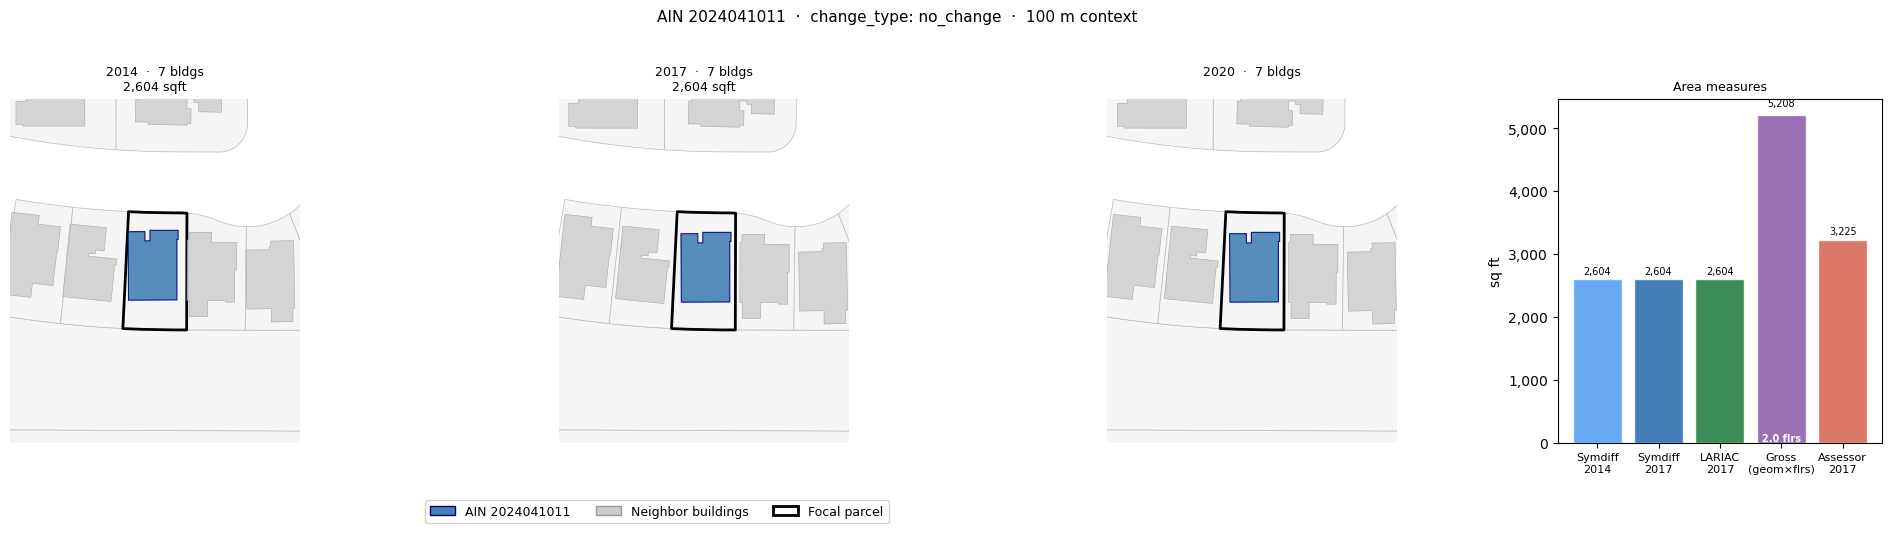

AIN 5425006023  |  LotArea 6,743 sqft  |  assr 3,059  |  lar_floor 5,101  |  ratio 1.67  |  Silver Lake
Assessor: https://portal.assessor.lacounty.gov/parceldetail/5425006023


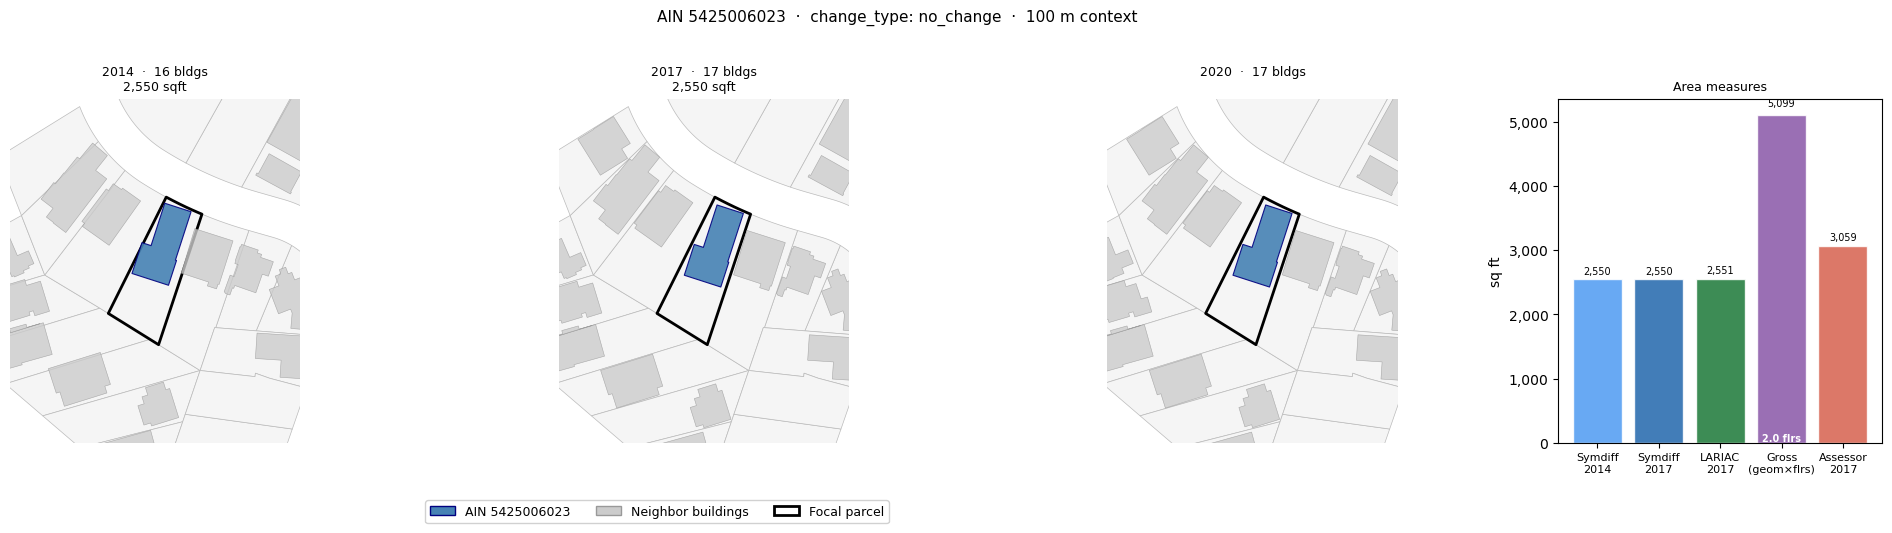

AIN 4320011003  |  LotArea 6,750 sqft  |  assr 2,121  |  lar_floor 2,568  |  ratio 1.21  |  West Los Angeles
Assessor: https://portal.assessor.lacounty.gov/parceldetail/4320011003


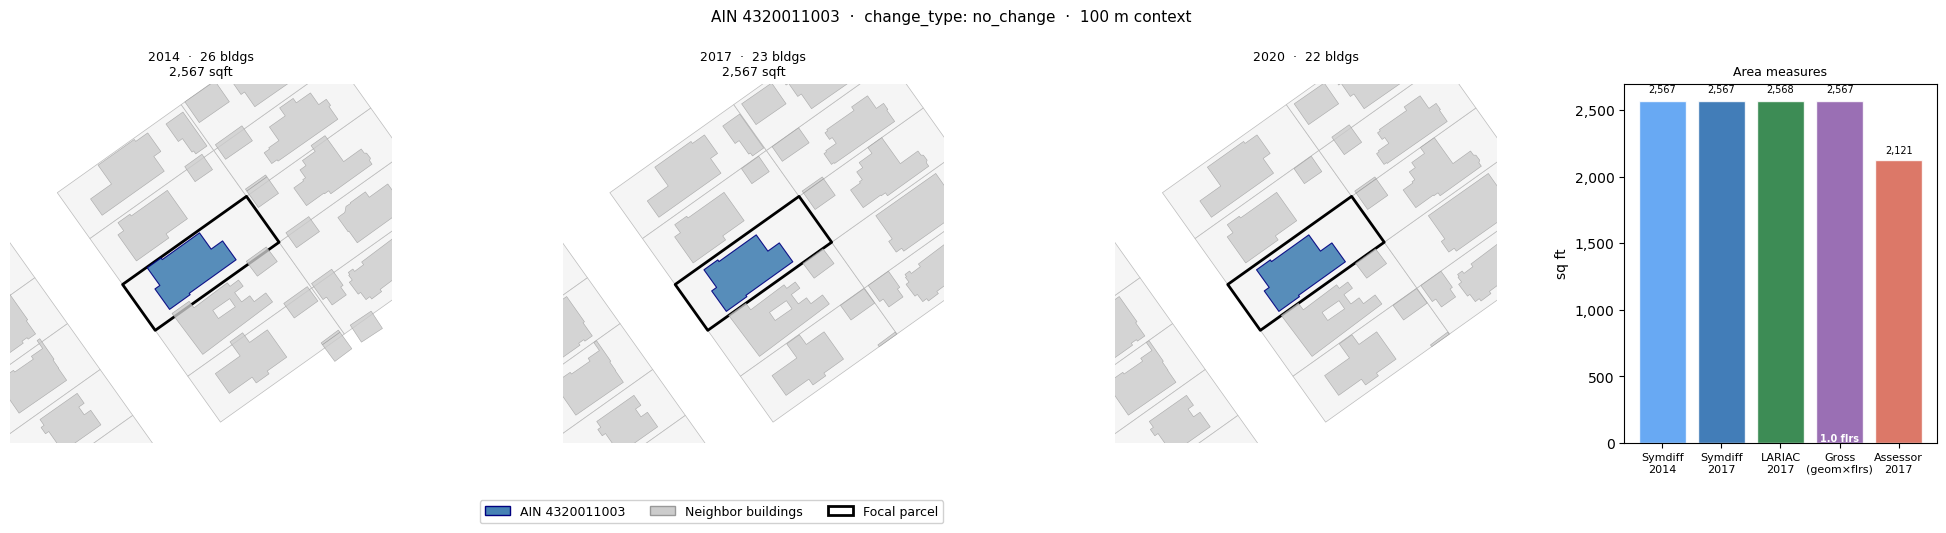

AIN 2181020010  |  LotArea 5,502 sqft  |  assr 1,429  |  lar_floor 2,076  |  ratio 1.45  |  Tarzana
Assessor: https://portal.assessor.lacounty.gov/parceldetail/2181020010


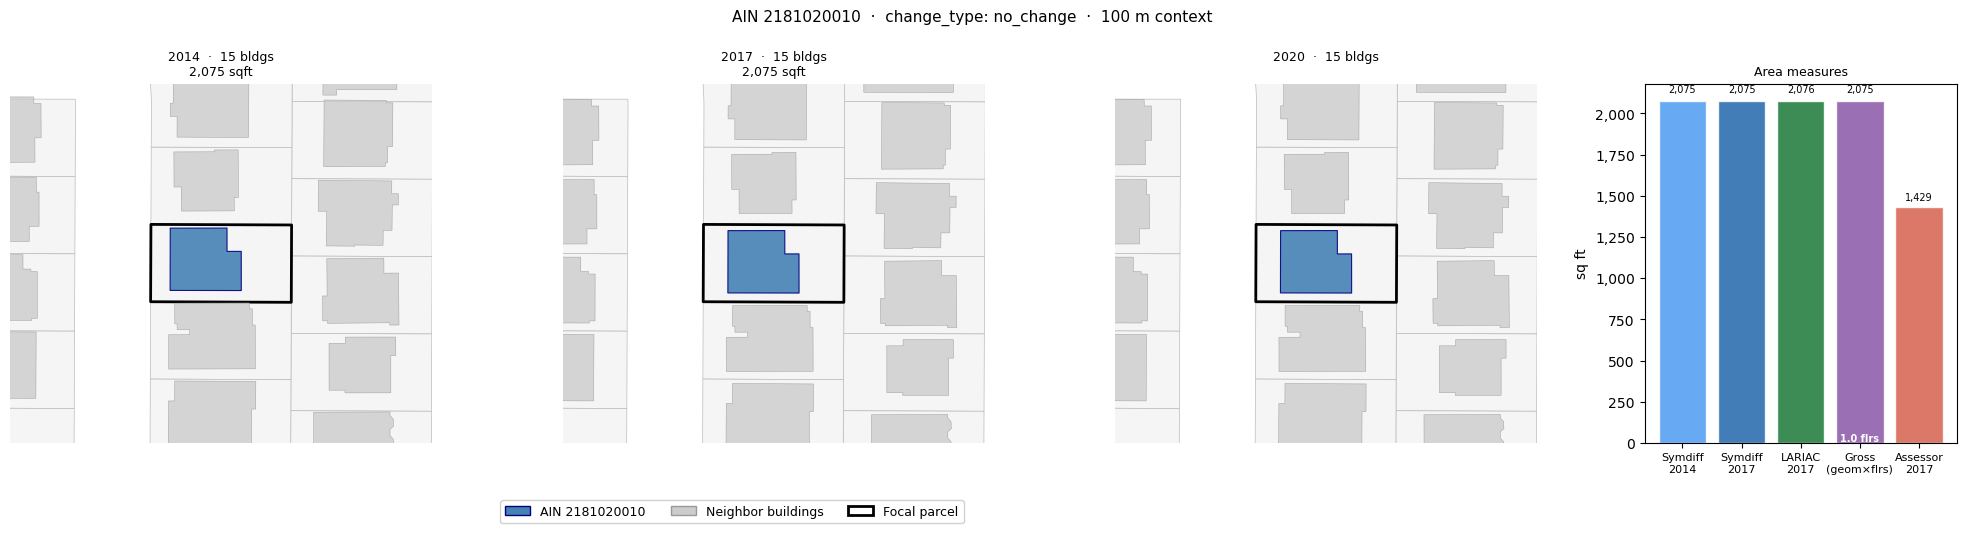

AIN 2531025075  |  LotArea 7,645 sqft  |  assr 2,616  |  lar_floor 3,638  |  ratio 1.39  |  Lake View Terrace
Assessor: https://portal.assessor.lacounty.gov/parceldetail/2531025075


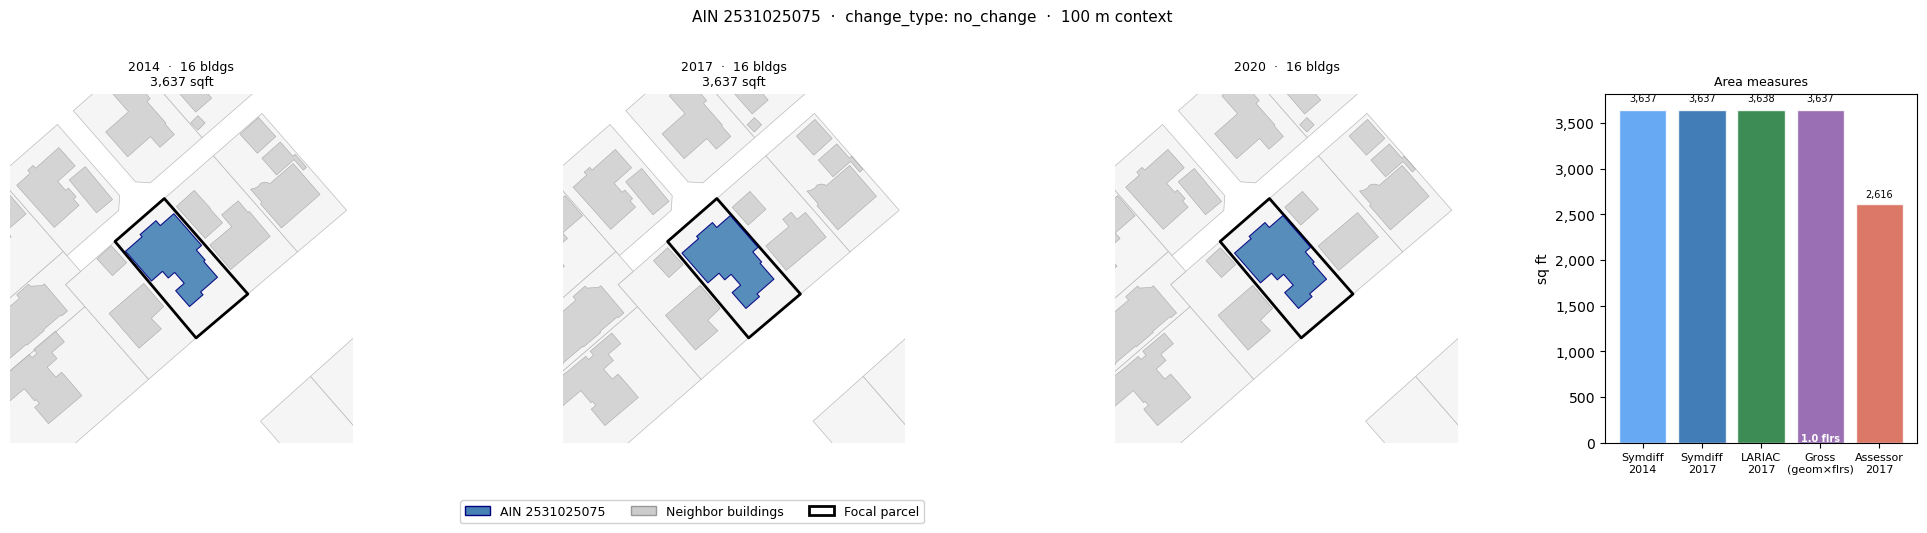

In [54]:
# Sample no-UDU candidates to inspect
# Use no_udu (clean columns); fall back to no_udu_clean if defined
pool = no_udu_clean if "no_udu_clean" in dir() and len(no_udu_clean) > 0 else no_udu
sample = pool.sample(5, random_state=42)

for _, row in sample.iterrows():
    lot  = row.get("LotArea",   row.get("LotArea_x",  float("nan")))
    larf = row.get("lar_floorarea", float("nan"))
    ratio = row.get("ratio_floor_assr", float("nan"))
    nbhd = row.get("neighborhood", row.get("Neighborhood", ""))
    print(f"AIN {row.AIN}  |  LotArea {lot:,.0f} sqft  |"
          f"  assr {row.assr_sqftmain:,.0f}  |  lar_floor {larf:,.0f}"
          f"  |  ratio {ratio:.2f}  |  {nbhd}")
    plot_ain_across_years(row.AIN, parcel_ref, merged=no_udu)


In [55]:
# ── Save checkpoints for reporting notebook (nb_10) ───────────────────��──────
# Fall back to no_udu if the contamination purge step has not been run
if 'no_udu_clean' not in dir():
    print("Warning: purge step not run — saving unfiltered no_udu set")
    no_udu_clean = no_udu

no_udu_clean[["AIN"]].drop_duplicates().to_csv(
    "data/04_results/no_udu_clean_ains.csv", index=False)
udu[["AIN"]].drop_duplicates().to_csv(
    "data/04_results/udu_ains.csv", index=False)

# Save symdiff-derived area metrics for nb_10
symdiff_cols = ["AIN","gross_sqft_geom","delta_gross_assr","area_2017_sqft","n_floors_lar"]
avail_cols   = [c for c in symdiff_cols if c in no_udu_clean.columns]
no_udu_clean[avail_cols].drop_duplicates("AIN").to_csv(
    "data/04_results/no_udu_symdiff_feats.csv", index=False)
avail_udu = [c for c in symdiff_cols if c in udu.columns]
udu[avail_udu].drop_duplicates("AIN").to_csv(
    "data/04_results/udu_symdiff_feats.csv", index=False)

print(f"no_udu AINs saved: {no_udu_clean['AIN'].nunique():,}")
print(f"udu    AINs saved: {udu['AIN'].nunique():,}")
print(f"Symdiff feat cols: {avail_cols}")


no_udu AINs saved: 190,716
udu    AINs saved: 433
Symdiff feat cols: ['AIN', 'gross_sqft_geom', 'delta_gross_assr', 'area_2017_sqft', 'n_floors_lar']
